<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/03b_Mia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install contextily

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


In [5]:
df = pd.read_csv('/content/drive/MyDrive/C255_final_project/cleaned/rbl_rde_cleaned.csv')

/tmp/ipykernel_28639/2197487421.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_start['business_start_date'] = pd.to_datetime(df_filtered_start['business_start_date'], errors='coerce')
/tmp/ipykernel_28639/2197487421.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_start['open_year'] = df_filtered_start['business_start_date'].dt.year


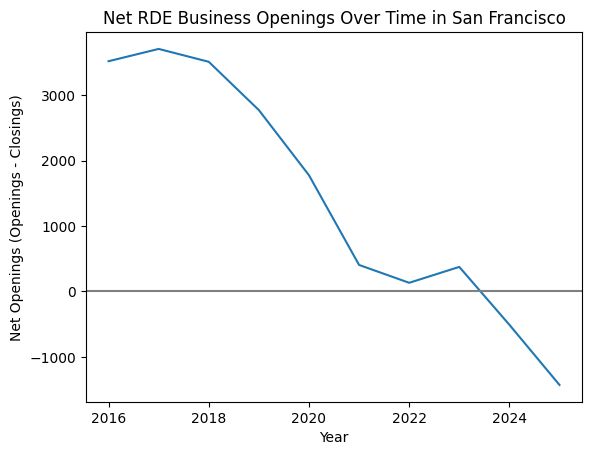

In [15]:
df['business_start_date'] = pd.to_datetime(df['business_start_date'], errors='coerce')
df_filtered_start = df[
    df['business_start_date'] >= '2016-01-01'
]
df_filtered_end = df_filtered[
    df_filtered['business_end_date'] < '2026-01-01'
]

df_filtered_start['business_start_date'] = pd.to_datetime(df_filtered_start['business_start_date'], errors='coerce')
df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')

df_filtered_start['open_year'] = df_filtered_start['business_start_date'].dt.year
df_filtered_end['close_year'] = df_filtered_end['business_end_date'].dt.year


# Counting openings and closings by year
openings = df_filtered_start.groupby('open_year').size()
closings = df_filtered_end.groupby('close_year').size()

# Combining into one dataframe
net = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

# Calculating net change
net['net_openings'] = net['openings'] - net['closings']

# Sorting by year
net = net.sort_index()

plt.figure()
plt.plot(net.index, net['net_openings'])
plt.xlabel('Year')
plt.ylabel('Net Openings (Openings - Closings)')
plt.title('Net RDE Business Openings Over Time in San Francisco')
plt.axhline(0, color='gray')
plt.show()

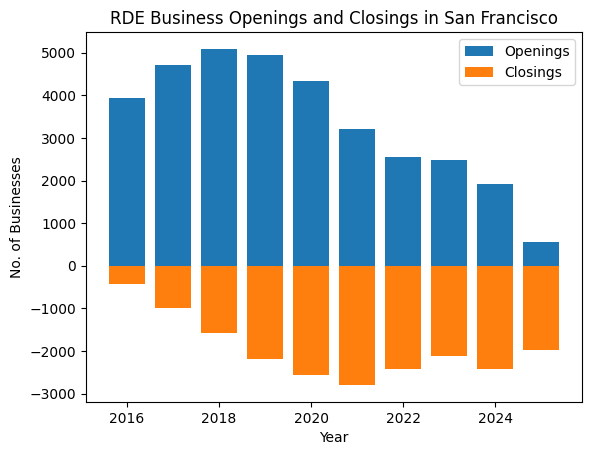

In [16]:

df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')

# Combining openings and closings
bars = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

# Making closings negative
bars['closings'] = -bars['closings']

# Sorting by year
bars = bars.sort_index()

plt.figure()
plt.bar(bars.index, bars['openings'], label='Openings')
plt.bar(bars.index, bars['closings'], label='Closings')
plt.xlabel('Year')
plt.ylabel('No. of Businesses')
plt.title('RDE Business Openings and Closings in San Francisco')
plt.legend()
plt.show()

In [18]:
openings = df_filtered_start.groupby('open_year').size()
openings

,0
open_year,
2016,3938
2017,4712
2018,5089
2019,4951
2020,4338
2021,3202
2022,2549
2023,2492
2024,1909


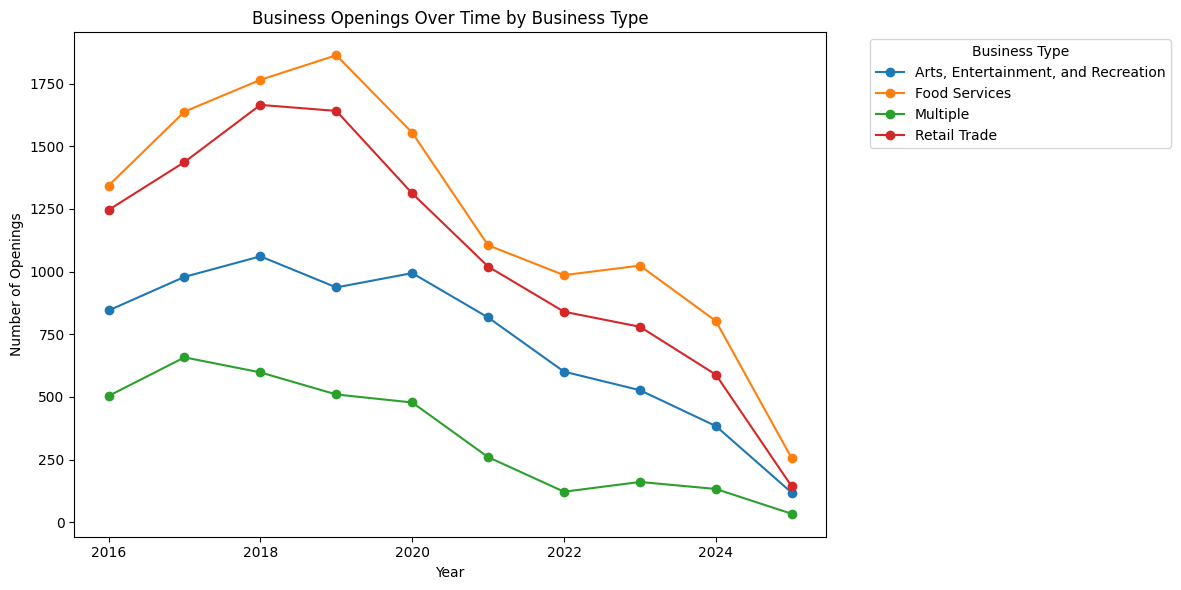

In [20]:
#Set up naics code descriptions to print and remove errant 2026 values
openings_by_type = df_filtered_start.groupby(['open_year', 'naics_code_description']).size().unstack(fill_value=0)
openings_by_type = openings_by_type[openings_by_type.index < 2026]

plt.figure(figsize=(12, 6))
for business_type in openings_by_type.columns:
    plt.plot(openings_by_type.index, openings_by_type[business_type], marker='o', label=business_type)

plt.title('Business Openings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Openings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

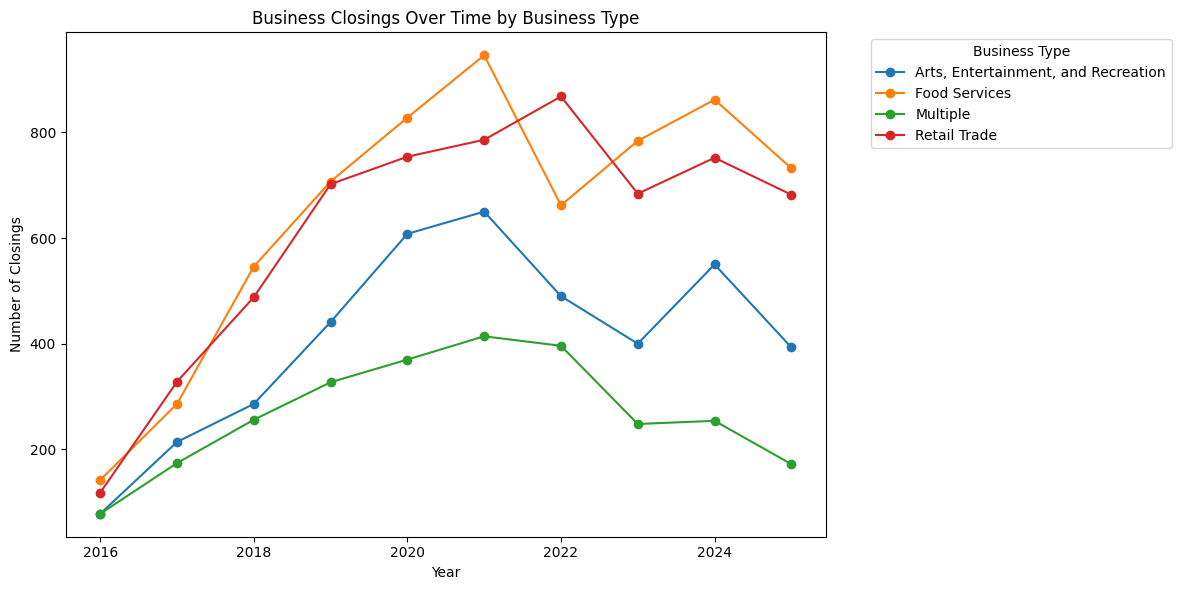

In [21]:
#Same thing for business closings
#Set up naics code descriptions to print and remove errant 2026 values
closings_by_type = df_filtered_end.groupby(['close_year', 'naics_code_description']).size().unstack(fill_value=0)
closings_by_type = closings_by_type[closings_by_type.index < 2026]

plt.figure(figsize=(12, 6))
for business_type in closings_by_type.columns:
    plt.plot(closings_by_type.index, closings_by_type[business_type], marker='o', label=business_type)

plt.title('Business Closings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Closings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()